In [26]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from scipy.stats import pearsonr

from common import *
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

In [27]:
import numpy as np

def normalize_abundance_dict(abundance_dict):
    """
    将丰度字典的 value 归一化，使其和为 1。
    
    参数：
        abundance_dict (dict): 例如 {'A': 10, 'B': 30, 'C': 60}
    
    返回：
        dict: 归一化后的字典，例如 {'A': 0.1, 'B': 0.3, 'C': 0.6}
    """
    values = np.array(list(abundance_dict.values()), dtype=float)
    total = values.sum()
    if total > 0:
        normalized_values = values / total
    else:
        normalized_values = np.zeros_like(values)
    
    # 保留 key 的对应关系
    normalized_dict = dict(zip(abundance_dict.keys(), normalized_values))
    return normalized_dict

# input and output

In [28]:
SA_abundance_file = '../../Data/scfa_predictions/data/raw_data/studyA_original_abundance.csv'
SA_scfas_file = '../../Data/scfa_predictions/data/raw_data/studyA_original_scfas.csv'

In [29]:
ref_family_list = {
    'Enterococcaceae': [],
    'Streptococcaceae': [],
    'Turicibacteraceae': [],
    'Enterobacteriaceae': [],
    'Alcaligenaceae': [],
    'Veillonellaceae': [],
    'Peptostreptococcaceae': [],
    'Porphyromonadaceae': [],
    'Erysipelotrichaceae': [],
    'Clostridiaceae': [],
    'Bifidobacteriaceae': [],
    'Rikenellaceae': [],
    'Bacteroidaceae': [],
    'Ruminococcaceae': [],
    'Lachnospiraceae': [],
}

def get_sampleID_abundance(sampleID,SA_abundance,ref_family_list):
    abundance = {}
    tmp_abundance = SA_abundance[SA_abundance['sample']==sampleID]
    all_abundance = tmp_abundance['reads'].sum()
    tmp_abundance['f'].value_counts()
    for family in ref_family_list:
        tmp = tmp_abundance[tmp_abundance['f']==family]
        if len(tmp)>0:
            abundance[family] = tmp['reads'].to_list()[0]/all_abundance
        else:
            # print(family)
            abundance[family] = 0
    return abundance   

# sampleID = 'B1'
# get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)

In [30]:
import math
def calculate_sampleID_score(abund_M,enzyme_count_N,family_list, abund_dict, enzyme_counts_dict):
    score = 0
    for family in family_list:
        abund = abund_dict.get(family, 0)
        enzyme_count = enzyme_counts_dict.get(family, 0)
        score += abund ** (abund_M) * enzyme_count ** (enzyme_count_N)
    return score

In [31]:
import json
with open('../../Result/ec_strain_enzymecounts_top4_filter_family.json', "r", encoding="utf-8") as f:
    enzyme_eccounts_dict = json.load(f)

print(enzyme_eccounts_dict)


import json
with open('../../Result/ec_strain_enzymecounts_top3_filter_family.json', "r", encoding="utf-8") as f:
    enzyme_eccounts_dict_top3 = json.load(f)

print(enzyme_eccounts_dict_top3)


{'7.2.2.21': {'Bifidobacteriaceae': 43, 'Bacteroidaceae': 78, 'Porphyromonadaceae': 3, 'Rikenellaceae': 13, 'Enterococcaceae': 1748, 'Streptococcaceae': 1122, 'Turicibacteraceae': 3, 'Clostridiaceae': 57, 'Lachnospiraceae': 65, 'Peptostreptococcaceae': 36, 'Ruminococcaceae': 3, 'Veillonellaceae': 9, 'Erysipelotrichaceae': 36, 'Alcaligenaceae': 12, 'Enterobacteriaceae': 3169}, '7.1.1.2': {'Bifidobacteriaceae': 75, 'Bacteroidaceae': 302, 'Porphyromonadaceae': 6, 'Rikenellaceae': 22, 'Enterococcaceae': 3801, 'Streptococcaceae': 2721, 'Turicibacteraceae': 30, 'Clostridiaceae': 327, 'Lachnospiraceae': 296, 'Peptostreptococcaceae': 110, 'Ruminococcaceae': 9, 'Veillonellaceae': 26, 'Erysipelotrichaceae': 157, 'Alcaligenaceae': 33, 'Enterobacteriaceae': 30305}, '2.7.1.202': {'Bifidobacteriaceae': 81, 'Bacteroidaceae': 234, 'Porphyromonadaceae': 6, 'Rikenellaceae': 26, 'Enterococcaceae': 4301, 'Streptococcaceae': 4788, 'Turicibacteraceae': 35, 'Clostridiaceae': 495, 'Lachnospiraceae': 379, 'Pep

In [32]:
enzyme_eccounts_dict['2.8.3.16']

{'Bifidobacteriaceae': 8,
 'Bacteroidaceae': 0,
 'Porphyromonadaceae': 0,
 'Rikenellaceae': 0,
 'Enterococcaceae': 0,
 'Streptococcaceae': 0,
 'Turicibacteraceae': 0,
 'Clostridiaceae': 1,
 'Lachnospiraceae': 2,
 'Peptostreptococcaceae': 11,
 'Ruminococcaceae': 0,
 'Veillonellaceae': 0,
 'Erysipelotrichaceae': 0,
 'Alcaligenaceae': 5,
 'Enterobacteriaceae': 972}

In [33]:
# acetate_ec_list = ['2.7.2.1','1.2.1.3','6.2.1.13']
# acetate_enzyme_counts_dict = {
#     '2.7.2.1':enzyme_eccounts_dict['2.7.2.1'],
#     '1.2.1.3':enzyme_eccounts_dict['1.2.1.3'],
#     '6.2.1.13':enzyme_eccounts_dict['6.2.1.13'],
#     }

# propionate_ec_list = ['2.7.2.1','2.7.2.15','6.2.1.1','6.2.1.17']
# propionate_enzyme_counts_dict = {
#     '2.7.2.1':enzyme_eccounts_dict['2.7.2.1'],
#     '2.7.2.15':enzyme_eccounts_dict['2.7.2.15'],
#     '6.2.1.1':enzyme_eccounts_dict['6.2.1.1'],
#     '6.2.1.17':enzyme_eccounts_dict['6.2.1.17'],
# }

# Butyrate_ec_list = ['2.8.3.8','1.3.8.1','2.7.2.7']
# Butyrate_enzyme_counts_dict = {
#     '2.8.3.8':enzyme_eccounts_dict['2.8.3.8'],
#     '1.3.8.1':enzyme_eccounts_dict['1.3.8.1'],
#     '2.7.2.7':enzyme_eccounts_dict['2.7.2.7'],
#     }


acetate_ec_list = ['2.7.2.1']
acetate_enzyme_counts_dict = {
    '2.7.2.1':enzyme_eccounts_dict['2.7.2.1'],
    }

propionate_ec_list = ['2.8.3','2.7.2.15']
propionate_enzyme_counts_dict = {
    '2.8.3':enzyme_eccounts_dict_top3['2.8.3'],
    '2.7.2.15':enzyme_eccounts_dict['2.7.2.15'],
}
# propionate_ec_list = ['2.8.3']
# propionate_enzyme_counts_dict = {
#     '2.8.3':enzyme_eccounts_dict_top3['2.8.3'],
# }

Butyrate_ec_list = ['2.8.3.8','2.7.2.7']
Butyrate_enzyme_counts_dict = {
    '2.8.3.8':enzyme_eccounts_dict['2.8.3.8'],
    '2.7.2.7':enzyme_eccounts_dict['2.7.2.7'],
    }


# 2-Methylbutyrate # 2-Methylbutyric acid
# Valerate   # Valeric acid
# Hexanoate  # Hexanoic acid
Methylbutyrate_ec_list = ['2.8.3']
Methylbutyrate_enzyme_counts_dict = {
    '2.8.3':enzyme_eccounts_dict_top3['2.8.3'],
}

Valerate_ec_list = ['2.8.3']
Valerate_enzyme_counts_dict = {
    '2.8.3':enzyme_eccounts_dict_top3['2.8.3'],
}

Hexanoate_ec_list = ['2.8.3']
Hexanoate_enzyme_counts_dict = {
    '2.8.3':enzyme_eccounts_dict_top3['2.8.3'],
}

SA_scfas = pd.read_csv(SA_scfas_file)
SA_abundance = pd.read_csv(SA_abundance_file)
MN_list = [1/4,1/3,1/2,1,2,3,4]


In [34]:
# from collections import defaultdict

# enzyme_counts_merged = defaultdict(int)
# for ec in Butyrate_ec_list:
#     ec_dict = Butyrate_enzyme_counts_dict[ec]
#     for fam, val in ec_dict.items():
#         enzyme_counts_merged[fam] += val
# enzyme_counts_merged = dict(enzyme_counts_merged)
# enzyme_counts_merged
# for ec in Butyrate_ec_list:
#     Butyrate_enzyme_counts_dict[ec] = enzyme_counts_merged
    
# enzyme_counts_merged = defaultdict(int)
# for ec in acetate_ec_list:
#     ec_dict = acetate_enzyme_counts_dict[ec]
#     for fam, val in ec_dict.items():
#         enzyme_counts_merged[fam] += val
# enzyme_counts_merged = dict(enzyme_counts_merged)
# enzyme_counts_merged
# for ec in acetate_ec_list:
#     acetate_enzyme_counts_dict[ec] = enzyme_counts_merged
    
# enzyme_counts_merged = defaultdict(int)
# for ec in propionate_ec_list:
#     ec_dict = propionate_enzyme_counts_dict[ec]
#     for fam, val in ec_dict.items():
#         enzyme_counts_merged[fam] += val
# enzyme_counts_merged = dict(enzyme_counts_merged)
# enzyme_counts_merged
# for ec in propionate_ec_list:
#     propionate_enzyme_counts_dict[ec] = enzyme_counts_merged

In [ ]:
Hexanoate_result = {
                    'sample_group':[],
                    'abund_M':[],
                   'enzyme_count_N':[],
                   'ecnumber':[],
                   'r':[],
                   'p':[]}
sample_pair_list = {
    'A1':'B1','A2':'B2','A3':'B3',
    'C1':'D1','C2':'D2','C3':'D3',
    'E1':'F1','E2':'F2','E3':'F3',
    'G1':'H1','G2':'H2','G3':'H3',
    'I1':'J1','I2':'J2','I3':'J3',
    'K1':'L1','K2':'L2','K3':'L3',
}

for abund_M in MN_list:
    for enzyme_count_N in MN_list:
        print('==========================')
        print('abund_M',abund_M)
        print('enzyme_count_N',enzyme_count_N)
        for ec in Hexanoate_ec_list:
            print('EC number',ec)
            enzyme_counts_dict = Hexanoate_enzyme_counts_dict[ec]

            vacid_syn_dict = {}
            for sampleID1,sampleID2 in sample_pair_list.items():
                tmp1 = SA_scfas[(SA_scfas['Unique Sample ID'] == sampleID1) &(SA_scfas['Time \nPoint'] == 'T0') &(SA_scfas['Analyte'] == 'Hexanoic acid')]
                tmp2 = SA_scfas[(SA_scfas['Unique Sample ID'] == sampleID2) &(SA_scfas['Time \nPoint'] == 'T1') &(SA_scfas['Analyte'] == 'Hexanoic acid')]    
                vacid_syn_dict[sampleID1] = tmp2['Result'].to_list()[0]- tmp1['Result'].to_list()[0]
            vacid_syn_dict

            vacid_score_dict = {}
            for sampleID,_ in vacid_syn_dict.items():
                # T1_sampleID = sample_pair_list[sampleID]
                # abundance_dict = get_sampleID_abundance(T1_sampleID,SA_abundance,ref_family_list)
                abundance_dict = get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)
                # print(abundance_dict)
                score = calculate_sampleID_score(abund_M,enzyme_count_N,ref_family_list, abundance_dict, enzyme_counts_dict)
                vacid_score_dict[sampleID] = score 
                # print(score)    

            # ===== 数据准备 =====
            keys = list(vacid_score_dict.keys())
            for i in range(0, len(keys), 6):

                group_keys = keys[i:i+6]

                x = [vacid_syn_dict[k] for k in group_keys]
                y = [vacid_score_dict[k] for k in group_keys]

                r, p = pearsonr(x, y)
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")
                r, p = pearsonr(x, np.log10(y))
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")

                Hexanoate_result['sample_group'].append(
                    f"group_{i//6+1}"
                )

                Hexanoate_result['abund_M'].append(abund_M)
                Hexanoate_result['enzyme_count_N'].append(enzyme_count_N)
                Hexanoate_result['ecnumber'].append(ec)
                Hexanoate_result['r'].append(r)
                Hexanoate_result['p'].append(p)            
            # x = [vacid_syn_dict[k] for k in keys]
            # y = [vacid_score_dict[k] for k in keys]

            # # x = [np.mean(x[i:i+3]) for i in range(0, len(x), 3)]
            # # y = [np.mean(y[i:i+3]) for i in range(0, len(y), 3)]

            # # ===== Pearson 相关性 =====
            # r, p = pearsonr(x, y)
            # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # r, p = pearsonr(x, np.log10(y))
            # # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # ===== 画布 & 样式 =====
            # plt.figure(figsize=(1, 1), dpi=300)
            # plt.rcParams.update({'font.size': 7})
            # plt.rcParams['font.family'] = 'Arial'
            # plt.rcParams['pdf.fonttype'] = 42

            # ax = plt.gca()
            # ax.spines['top'].set_linewidth(0)
            # ax.spines['bottom'].set_linewidth(1)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['right'].set_linewidth(0)
            # ax.set_position([0.2, 0.2, 0.8, 0.8]) 

            # # ===== 散点图 =====
            # plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

            # # 在点旁边显示 label
            # for i, k in enumerate(keys):
            #     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

            # # y轴对数
            # # plt.yscale("log")

            # # 在图上显示相关性
            # plt.text(0.68, 0.25, f"N = 19\nr = {r:.2f}\np = {p:.1e}",
            #         transform=plt.gca().transAxes,
            #         fontsize=7, fontweight='bold', va="top", ha='left')

            # # ===== 坐标轴 =====
            # plt.xlabel("Levodopa consumption (%)", fontsize=7, fontweight='bold')
            # plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')

            # plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
            # plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

            # # plt.xlim(0.35, 0.95)
            # # plt.ylim(1e8, 5.5e8)

            # plt.show()
            # # 用于参数筛选的相关性
            # # if p < 0.05:
            # #     r = r
            # # else:
            # #     r = 0            
            # Hexanoate_result['abund_M'].append(abund_M)
            # Hexanoate_result['enzyme_count_N'].append(enzyme_count_N)
            # Hexanoate_result['ecnumber'].append(ec)
            # Hexanoate_result['r'].append(r)
            # Hexanoate_result['p'].append(p)

abund_M 0.25
enzyme_count_N 0.25
EC number 2.8.3
Pearson r = -0.414, p = 4.149e-01
Pearson r = -0.414, p = 4.148e-01
Pearson r = 0.956, p = 2.812e-03
Pearson r = 0.959, p = 2.437e-03
Pearson r = 0.548, p = 2.606e-01
Pearson r = 0.549, p = 2.595e-01
abund_M 0.25
enzyme_count_N 0.3333333333333333
EC number 2.8.3
Pearson r = -0.341, p = 5.086e-01
Pearson r = -0.341, p = 5.089e-01
Pearson r = 0.933, p = 6.534e-03
Pearson r = 0.938, p = 5.668e-03
Pearson r = 0.459, p = 3.596e-01
Pearson r = 0.458, p = 3.610e-01
abund_M 0.25
enzyme_count_N 0.5
EC number 2.8.3
Pearson r = -0.237, p = 6.517e-01
Pearson r = -0.236, p = 6.524e-01
Pearson r = 0.844, p = 3.467e-02
Pearson r = 0.853, p = 3.083e-02
Pearson r = 0.364, p = 4.783e-01
Pearson r = 0.357, p = 4.876e-01
abund_M 0.25
enzyme_count_N 1
EC number 2.8.3
Pearson r = -0.128, p = 8.085e-01
Pearson r = -0.127, p = 8.098e-01
Pearson r = 0.440, p = 3.823e-01
Pearson r = 0.438, p = 3.845e-01
Pearson r = 0.307, p = 5.534e-01
Pearson r = 0.285, p = 5.83

In [ ]:
Valerate_result = {
                    'sample_group':[],
                    'abund_M':[],
                   'enzyme_count_N':[],
                   'ecnumber':[],
                   'r':[],
                   'p':[]}
sample_pair_list = {
    'A1':'B1','A2':'B2','A3':'B3',
    'C1':'D1','C2':'D2','C3':'D3',
    'E1':'F1','E2':'F2','E3':'F3',
    'G1':'H1','G2':'H2','G3':'H3',
    'I1':'J1','I2':'J2','I3':'J3',
    'K1':'L1','K2':'L2','K3':'L3',
}

for abund_M in MN_list:
    for enzyme_count_N in MN_list:
        print('==========================')
        print('abund_M',abund_M)
        print('enzyme_count_N',enzyme_count_N)
        for ec in Valerate_ec_list:
            print('EC number',ec)
            enzyme_counts_dict = Valerate_enzyme_counts_dict[ec]

            vacid_syn_dict = {}
            for sampleID1,sampleID2 in sample_pair_list.items():
                tmp1 = SA_scfas[(SA_scfas['Unique Sample ID'] == sampleID1) &(SA_scfas['Time \nPoint'] == 'T0') &(SA_scfas['Analyte'] == 'Valeric acid')]
                tmp2 = SA_scfas[(SA_scfas['Unique Sample ID'] == sampleID2) &(SA_scfas['Time \nPoint'] == 'T1') &(SA_scfas['Analyte'] == 'Valeric acid')]    
                vacid_syn_dict[sampleID1] = tmp2['Result'].to_list()[0]- tmp1['Result'].to_list()[0]
            vacid_syn_dict

            vacid_score_dict = {}
            for sampleID,_ in vacid_syn_dict.items():
                # T1_sampleID = sample_pair_list[sampleID]
                # abundance_dict = get_sampleID_abundance(T1_sampleID,SA_abundance,ref_family_list)
                abundance_dict = get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)
                # print(abundance_dict)
                score = calculate_sampleID_score(abund_M,enzyme_count_N,ref_family_list, abundance_dict, enzyme_counts_dict)
                vacid_score_dict[sampleID] = score 
                # print(score)    

            # ===== 数据准备 =====
            keys = list(vacid_score_dict.keys())
            for i in range(0, len(keys), 6):

                group_keys = keys[i:i+6]

                x = [vacid_syn_dict[k] for k in group_keys]
                y = [vacid_score_dict[k] for k in group_keys]

                r, p = pearsonr(x, y)
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")
                r, p = pearsonr(x, np.log10(y))
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")

                Valerate_result['sample_group'].append(
                    f"group_{i//6+1}"
                )

                Valerate_result['abund_M'].append(abund_M)
                Valerate_result['enzyme_count_N'].append(enzyme_count_N)
                Valerate_result['ecnumber'].append(ec)
                Valerate_result['r'].append(r)
                Valerate_result['p'].append(p)   
            # x = [vacid_syn_dict[k] for k in keys]
            # y = [vacid_score_dict[k] for k in keys]

            # # x = [np.mean(x[i:i+3]) for i in range(0, len(x), 3)]
            # # y = [np.mean(y[i:i+3]) for i in range(0, len(y), 3)]

            # # ===== Pearson 相关性 =====
            # r, p = pearsonr(x, y)
            # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # r, p = pearsonr(x, np.log10(y))
            # # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # ===== 画布 & 样式 =====
            # plt.figure(figsize=(1, 1), dpi=300)
            # plt.rcParams.update({'font.size': 7})
            # plt.rcParams['font.family'] = 'Arial'
            # plt.rcParams['pdf.fonttype'] = 42

            # ax = plt.gca()
            # ax.spines['top'].set_linewidth(0)
            # ax.spines['bottom'].set_linewidth(1)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['right'].set_linewidth(0)
            # ax.set_position([0.2, 0.2, 0.8, 0.8]) 

            # # ===== 散点图 =====
            # plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

            # # 在点旁边显示 label
            # for i, k in enumerate(keys):
            #     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

            # # y轴对数
            # # plt.yscale("log")

            # # 在图上显示相关性
            # plt.text(0.68, 0.25, f"N = 19\nr = {r:.2f}\np = {p:.1e}",
            #         transform=plt.gca().transAxes,
            #         fontsize=7, fontweight='bold', va="top", ha='left')

            # # ===== 坐标轴 =====
            # plt.xlabel("Levodopa consumption (%)", fontsize=7, fontweight='bold')
            # plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')

            # plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
            # plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

            # # plt.xlim(0.35, 0.95)
            # # plt.ylim(1e8, 5.5e8)

            # plt.show()
            # # 用于参数筛选的相关性
            # # if p < 0.05:
            # #     r = r
            # # else:
            # #     r = 0            
            # Valerate_result['abund_M'].append(abund_M)
            # Valerate_result['enzyme_count_N'].append(enzyme_count_N)
            # Valerate_result['ecnumber'].append(ec)
            # Valerate_result['r'].append(r)
            # Valerate_result['p'].append(p)

abund_M 0.25
enzyme_count_N 0.25
EC number 2.8.3
Pearson r = 0.358, p = 4.856e-01
Pearson r = 0.356, p = 4.889e-01
Pearson r = 0.914, p = 1.084e-02
Pearson r = 0.917, p = 1.005e-02
Pearson r = -0.472, p = 3.449e-01
Pearson r = -0.473, p = 3.435e-01
abund_M 0.25
enzyme_count_N 0.3333333333333333
EC number 2.8.3
Pearson r = 0.358, p = 4.864e-01
Pearson r = 0.356, p = 4.890e-01
Pearson r = 0.890, p = 1.740e-02
Pearson r = 0.895, p = 1.601e-02
Pearson r = -0.397, p = 4.353e-01
Pearson r = -0.397, p = 4.360e-01
abund_M 0.25
enzyme_count_N 0.5
EC number 2.8.3
Pearson r = 0.350, p = 4.968e-01
Pearson r = 0.349, p = 4.978e-01
Pearson r = 0.802, p = 5.482e-02
Pearson r = 0.811, p = 5.035e-02
Pearson r = -0.321, p = 5.351e-01
Pearson r = -0.316, p = 5.419e-01
abund_M 0.25
enzyme_count_N 1
EC number 2.8.3
Pearson r = 0.335, p = 5.162e-01
Pearson r = 0.338, p = 5.129e-01
Pearson r = 0.412, p = 4.166e-01
Pearson r = 0.411, p = 4.178e-01
Pearson r = -0.281, p = 5.893e-01
Pearson r = -0.265, p = 6.11

In [ ]:
Methylbutyrate_result = {
                    'sample_group':[],
                    'abund_M':[],
                   'enzyme_count_N':[],
                   'ecnumber':[],
                   'r':[],
                   'p':[]}


sample_pair_list = {
    'A1':'B1','A2':'B2','A3':'B3',
    'C1':'D1','C2':'D2','C3':'D3',
    'E1':'F1','E2':'F2','E3':'F3',
    'G1':'H1','G2':'H2','G3':'H3',
    'I1':'J1','I2':'J2','I3':'J3',
    'K1':'L1','K2':'L2','K3':'L3',
}



for abund_M in MN_list:
    for enzyme_count_N in MN_list:
        print('==========================')
        print('abund_M',abund_M)
        print('enzyme_count_N',enzyme_count_N)
        for ec in Methylbutyrate_ec_list:
            print('EC number',ec)
            enzyme_counts_dict = Methylbutyrate_enzyme_counts_dict[ec]

            vacid_syn_dict = {}
            for sampleID1,sampleID2 in sample_pair_list.items():
                tmp1 = SA_scfas[(SA_scfas['Unique Sample ID'] == sampleID1) &(SA_scfas['Time \nPoint'] == 'T0') &(SA_scfas['Analyte'] == '2-Methylbutyric acid')]
                tmp2 = SA_scfas[(SA_scfas['Unique Sample ID'] == sampleID2) &(SA_scfas['Time \nPoint'] == 'T1') &(SA_scfas['Analyte'] == '2-Methylbutyric acid')]    
                vacid_syn_dict[sampleID1] = tmp2['Result'].to_list()[0]- tmp1['Result'].to_list()[0]
            vacid_syn_dict

            vacid_score_dict = {}
            for sampleID,_ in vacid_syn_dict.items():
                # T1_sampleID = sample_pair_list[sampleID]
                # abundance_dict = get_sampleID_abundance(T1_sampleID,SA_abundance,ref_family_list)
                abundance_dict = get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)
                # print(abundance_dict)
                score = calculate_sampleID_score(abund_M,enzyme_count_N,ref_family_list, abundance_dict, enzyme_counts_dict)
                vacid_score_dict[sampleID] = score 
                # print(score)    

            # ===== 数据准备 =====
            keys = list(vacid_score_dict.keys())
            for i in range(0, len(keys), 6):

                group_keys = keys[i:i+6]

                x = [vacid_syn_dict[k] for k in group_keys]
                y = [vacid_score_dict[k] for k in group_keys]

                r, p = pearsonr(x, y)
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")
                r, p = pearsonr(x, np.log10(y))
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")

                Methylbutyrate_result['sample_group'].append(
                    f"group_{i//6+1}"
                )

                Methylbutyrate_result['abund_M'].append(abund_M)
                Methylbutyrate_result['enzyme_count_N'].append(enzyme_count_N)
                Methylbutyrate_result['ecnumber'].append(ec)
                Methylbutyrate_result['r'].append(r)
                Methylbutyrate_result['p'].append(p) 
            # x = [vacid_syn_dict[k] for k in keys]
            # y = [vacid_score_dict[k] for k in keys]

            # # x = [np.mean(x[i:i+3]) for i in range(0, len(x), 3)]
            # # y = [np.mean(y[i:i+3]) for i in range(0, len(y), 3)]

            # # ===== Pearson 相关性 =====
            # r, p = pearsonr(x, y)
            # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # r, p = pearsonr(x, np.log10(y))
            # # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # ===== 画布 & 样式 =====
            # plt.figure(figsize=(1, 1), dpi=300)
            # plt.rcParams.update({'font.size': 7})
            # plt.rcParams['font.family'] = 'Arial'
            # plt.rcParams['pdf.fonttype'] = 42

            # ax = plt.gca()
            # ax.spines['top'].set_linewidth(0)
            # ax.spines['bottom'].set_linewidth(1)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['right'].set_linewidth(0)
            # ax.set_position([0.2, 0.2, 0.8, 0.8]) 

            # # ===== 散点图 =====
            # plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

            # # 在点旁边显示 label
            # for i, k in enumerate(keys):
            #     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

            # # y轴对数
            # # plt.yscale("log")

            # # 在图上显示相关性
            # plt.text(0.68, 0.25, f"N = 19\nr = {r:.2f}\np = {p:.1e}",
            #         transform=plt.gca().transAxes,
            #         fontsize=7, fontweight='bold', va="top", ha='left')

            # # ===== 坐标轴 =====
            # plt.xlabel("Levodopa consumption (%)", fontsize=7, fontweight='bold')
            # plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')

            # plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
            # plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

            # # plt.xlim(0.35, 0.95)
            # # plt.ylim(1e8, 5.5e8)

            # plt.show()
            # # 用于参数筛选的相关性
            # # if p < 0.05:
            # #     r = r
            # # else:
            # #     r = 0            
            # Methylbutyrate_result['abund_M'].append(abund_M)
            # Methylbutyrate_result['enzyme_count_N'].append(enzyme_count_N)
            # Methylbutyrate_result['ecnumber'].append(ec)
            # Methylbutyrate_result['r'].append(r)
            # Methylbutyrate_result['p'].append(p)

abund_M 0.25
enzyme_count_N 0.25
EC number 2.8.3
Pearson r = 0.766, p = 7.544e-02
Pearson r = 0.768, p = 7.468e-02
Pearson r = -0.942, p = 5.000e-03
Pearson r = -0.945, p = 4.385e-03
Pearson r = -0.416, p = 4.123e-01
Pearson r = -0.417, p = 4.109e-01
abund_M 0.25
enzyme_count_N 0.3333333333333333
EC number 2.8.3
Pearson r = 0.817, p = 4.739e-02
Pearson r = 0.818, p = 4.669e-02
Pearson r = -0.915, p = 1.044e-02
Pearson r = -0.921, p = 9.119e-03
Pearson r = -0.323, p = 5.328e-01
Pearson r = -0.322, p = 5.343e-01
abund_M 0.25
enzyme_count_N 0.5
EC number 2.8.3
Pearson r = 0.872, p = 2.353e-02
Pearson r = 0.874, p = 2.287e-02
Pearson r = -0.818, p = 4.665e-02
Pearson r = -0.829, p = 4.151e-02
Pearson r = -0.225, p = 6.679e-01
Pearson r = -0.218, p = 6.779e-01
abund_M 0.25
enzyme_count_N 1
EC number 2.8.3
Pearson r = 0.911, p = 1.144e-02
Pearson r = 0.915, p = 1.062e-02
Pearson r = -0.400, p = 4.326e-01
Pearson r = -0.399, p = 4.331e-01
Pearson r = -0.170, p = 7.479e-01
Pearson r = -0.148, 

In [ ]:
Butyrate_result = {
                    'sample_group':[],
                    'abund_M':[],
                   'enzyme_count_N':[],
                   'ecnumber':[],
                   'r':[],
                   'p':[]}
sample_pair_list = {
    'A1':'B1','A2':'B2','A3':'B3',
    'C1':'D1','C2':'D2','C3':'D3',
    'E1':'F1','E2':'F2','E3':'F3',
    'G1':'H1','G2':'H2','G3':'H3',
    'I1':'J1','I2':'J2','I3':'J3',
    'K1':'L1','K2':'L2','K3':'L3',
}

for abund_M in MN_list:
    for enzyme_count_N in MN_list:
        print('==========================')
        print('abund_M',abund_M)
        print('enzyme_count_N',enzyme_count_N)
        for ec in Butyrate_ec_list:
            print('EC number',ec)
            enzyme_counts_dict = Butyrate_enzyme_counts_dict[ec]

            vacid_syn_dict = {}
            for sampleID1,sampleID2 in sample_pair_list.items():
                tmp1 = SA_scfas[
                    (SA_scfas['Unique Sample ID'] == sampleID1) &
                    (SA_scfas['Time \nPoint'] == 'T0') &
                    (SA_scfas['Analyte'] == 'Butyric acid')
                ]
                tmp2 = SA_scfas[
                    (SA_scfas['Unique Sample ID'] == sampleID2) &
                    (SA_scfas['Time \nPoint'] == 'T1') &
                    (SA_scfas['Analyte'] == 'Butyric acid')
                ]    
                vacid_syn_dict[sampleID1] = tmp2['Result'].to_list()[0]- tmp1['Result'].to_list()[0]
            vacid_syn_dict

            vacid_score_dict = {}
            for sampleID,_ in vacid_syn_dict.items():
                # T1_sampleID = sample_pair_list[sampleID]
                # abundance_dict = get_sampleID_abundance(T1_sampleID,SA_abundance,ref_family_list)
                abundance_dict = get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)
                # print(abundance_dict)
                score = calculate_sampleID_score(abund_M,enzyme_count_N,ref_family_list, abundance_dict, enzyme_counts_dict)
                vacid_score_dict[sampleID] = score 
                # print(score)    

            # ===== 数据准备 =====
            keys = list(vacid_score_dict.keys())
            for i in range(0, len(keys), 6):

                group_keys = keys[i:i+6]

                x = [vacid_syn_dict[k] for k in group_keys]
                y = [vacid_score_dict[k] for k in group_keys]

                r, p = pearsonr(x, y)
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")
                r, p = pearsonr(x, np.log10(y))
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")

                Butyrate_result['sample_group'].append(
                    f"group_{i//6+1}"
                )

                Butyrate_result['abund_M'].append(abund_M)
                Butyrate_result['enzyme_count_N'].append(enzyme_count_N)
                Butyrate_result['ecnumber'].append(ec)
                Butyrate_result['r'].append(r)
                Butyrate_result['p'].append(p) 
            # # keys = [x for x in keys if x not in ['0611A', '0610C','0707B','0421A']]
            # x = [vacid_syn_dict[k] for k in keys]
            # y = [vacid_score_dict[k] for k in keys]

            # # x = [np.mean(x[i:i+3]) for i in range(0, len(x), 3)]
            # # y = [np.mean(y[i:i+3]) for i in range(0, len(y), 3)]

            # # ===== Pearson 相关性 =====
            # r, p = pearsonr(x, y)
            # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # r, p = pearsonr(x, np.log10(y))
            # # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # ===== 画布 & 样式 =====
            # plt.figure(figsize=(1, 1), dpi=300)
            # plt.rcParams.update({'font.size': 7})
            # plt.rcParams['font.family'] = 'Arial'
            # plt.rcParams['pdf.fonttype'] = 42

            # ax = plt.gca()
            # ax.spines['top'].set_linewidth(0)
            # ax.spines['bottom'].set_linewidth(1)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['right'].set_linewidth(0)
            # ax.set_position([0.2, 0.2, 0.8, 0.8]) 

            # # ===== 散点图 =====
            # plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

            # # 在点旁边显示 label
            # for i, k in enumerate(keys):
            #     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

            # # y轴对数
            # # plt.yscale("log")

            # # 在图上显示相关性
            # plt.text(0.68, 0.25, f"N = 19\nr = {r:.2f}\np = {p:.1e}",
            #         transform=plt.gca().transAxes,
            #         fontsize=7, fontweight='bold', va="top", ha='left')

            # # ===== 坐标轴 =====
            # plt.xlabel("Levodopa consumption (%)", fontsize=7, fontweight='bold')
            # plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')

            # plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
            # plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

            # # plt.xlim(0.35, 0.95)
            # # plt.ylim(1e8, 5.5e8)

            # # plt.show()
            
            
            # # 用于参数筛选的相关性
            # # if p < 0.05:
            # #     r = r
            # # else:
            # #     r = 0
            # Butyrate_result['abund_M'].append(abund_M)
            # Butyrate_result['enzyme_count_N'].append(enzyme_count_N)
            # Butyrate_result['ecnumber'].append(ec)
            # Butyrate_result['r'].append(r)
            # Butyrate_result['p'].append(p)

abund_M 0.25
enzyme_count_N 0.25
EC number 2.8.3.8
Pearson r = 0.490, p = 3.239e-01
Pearson r = 0.488, p = 3.258e-01
Pearson r = 0.860, p = 2.788e-02
Pearson r = 0.866, p = 2.592e-02
Pearson r = 0.232, p = 6.584e-01
Pearson r = 0.225, p = 6.687e-01
EC number 2.7.2.7
Pearson r = 0.625, p = 1.848e-01
Pearson r = 0.624, p = 1.855e-01
Pearson r = 0.983, p = 4.266e-04
Pearson r = 0.984, p = 3.737e-04
Pearson r = 0.584, p = 2.234e-01
Pearson r = 0.585, p = 2.223e-01
abund_M 0.25
enzyme_count_N 0.3333333333333333
EC number 2.8.3.8
Pearson r = 0.380, p = 4.569e-01
Pearson r = 0.379, p = 4.589e-01
Pearson r = 0.762, p = 7.851e-02
Pearson r = 0.768, p = 7.463e-02
Pearson r = 0.254, p = 6.270e-01
Pearson r = 0.245, p = 6.399e-01
EC number 2.7.2.7
Pearson r = 0.566, p = 2.412e-01
Pearson r = 0.566, p = 2.420e-01
Pearson r = 0.982, p = 4.826e-04
Pearson r = 0.983, p = 4.170e-04
Pearson r = 0.503, p = 3.089e-01
Pearson r = 0.503, p = 3.087e-01
abund_M 0.25
enzyme_count_N 0.5
EC number 2.8.3.8
Pearso

In [ ]:
acetate_result = {                    
                  'sample_group':[],
                    'abund_M':[],
                   'enzyme_count_N':[],
                   'ecnumber':[],
                   'r':[],
                   'p':[]}


sample_pair_list = {
    'A1':'B1','A2':'B2','A3':'B3',
    'C1':'D1','C2':'D2','C3':'D3',
    'E1':'F1','E2':'F2','E3':'F3',
    'G1':'H1','G2':'H2','G3':'H3',
    'I1':'J1','I2':'J2','I3':'J3',
    'K1':'L1','K2':'L2','K3':'L3',
}

for abund_M in MN_list:
    for enzyme_count_N in MN_list:
        print('==========================')
        print('abund_M',abund_M)
        print('enzyme_count_N',enzyme_count_N)
        for ec in acetate_ec_list:
            print('EC number',ec)
            enzyme_counts_dict = acetate_enzyme_counts_dict[ec]

            vacid_syn_dict = {}
            for sampleID1,sampleID2 in sample_pair_list.items():
                tmp1 = SA_scfas[
                    (SA_scfas['Unique Sample ID'] == sampleID1) &
                    (SA_scfas['Time \nPoint'] == 'T0') &
                    (SA_scfas['Analyte'] == 'Acetic acid')
                ]
                tmp2 = SA_scfas[
                    (SA_scfas['Unique Sample ID'] == sampleID2) &
                    (SA_scfas['Time \nPoint'] == 'T1') &
                    (SA_scfas['Analyte'] == 'Acetic acid')
                ]    
                vacid_syn_dict[sampleID1] = tmp2['Result'].to_list()[0]- tmp1['Result'].to_list()[0]
            vacid_syn_dict

            vacid_score_dict = {}
            for sampleID,_ in vacid_syn_dict.items():
                # T1_sampleID = sample_pair_list[sampleID]
                # abundance_dict = get_sampleID_abundance(T1_sampleID,SA_abundance,ref_family_list)
                abundance_dict = get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)
                # print(abundance_dict)
                score = calculate_sampleID_score(abund_M,enzyme_count_N,ref_family_list, abundance_dict, enzyme_counts_dict)
                vacid_score_dict[sampleID] = score 
                # print(score)    

            # ===== 数据准备 =====
            keys = list(vacid_score_dict.keys())
            for i in range(0, len(keys), 6):

                group_keys = keys[i:i+6]

                x = [vacid_syn_dict[k] for k in group_keys]
                y = [vacid_score_dict[k] for k in group_keys]

                r, p = pearsonr(x, y)
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")
                r, p = pearsonr(x, np.log10(y))
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")

                acetate_result['sample_group'].append(
                    f"group_{i//6+1}"
                )

                acetate_result['abund_M'].append(abund_M)
                acetate_result['enzyme_count_N'].append(enzyme_count_N)
                acetate_result['ecnumber'].append(ec)
                acetate_result['r'].append(r)
                acetate_result['p'].append(p) 
            # # keys = [x for x in keys if x not in ['0611A', '0610C','0707B','0421A']]
            # x = [vacid_syn_dict[k] for k in keys]
            # y = [vacid_score_dict[k] for k in keys]

            # # x = [np.mean(x[i:i+3]) for i in range(0, len(x), 3)]
            # # y = [np.mean(y[i:i+3]) for i in range(0, len(y), 3)]

            # # ===== Pearson 相关性 =====
            # r, p = pearsonr(x, y)
            # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # r, p = pearsonr(x, np.log10(y))
            # # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # ===== 画布 & 样式 =====
            # plt.figure(figsize=(1, 1), dpi=300)
            # plt.rcParams.update({'font.size': 7})
            # plt.rcParams['font.family'] = 'Arial'
            # plt.rcParams['pdf.fonttype'] = 42

            # ax = plt.gca()
            # ax.spines['top'].set_linewidth(0)
            # ax.spines['bottom'].set_linewidth(1)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['right'].set_linewidth(0)
            # ax.set_position([0.2, 0.2, 0.8, 0.8]) 

            # # ===== 散点图 =====
            # plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

            # # 在点旁边显示 label
            # for i, k in enumerate(keys):
            #     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

            # # y轴对数
            # # plt.yscale("log")

            # # 在图上显示相关性
            # plt.text(0.68, 0.25, f"N = 19\nr = {r:.2f}\np = {p:.1e}",
            #         transform=plt.gca().transAxes,
            #         fontsize=7, fontweight='bold', va="top", ha='left')

            # # ===== 坐标轴 =====
            # plt.xlabel("Levodopa consumption (%)", fontsize=7, fontweight='bold')
            # plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')

            # plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
            # plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

            # # plt.xlim(0.35, 0.95)
            # # plt.ylim(1e8, 5.5e8)

            # # plt.show()
            # # 用于参数筛选的相关性
            # # if p < 0.05:
            # #     r = r
            # # else:
            # #     r = 0
            # acetate_result['abund_M'].append(abund_M)
            # acetate_result['enzyme_count_N'].append(enzyme_count_N)
            # acetate_result['ecnumber'].append(ec)
            # acetate_result['r'].append(r)
            # acetate_result['p'].append(p)

abund_M 0.25
enzyme_count_N 0.25
EC number 2.7.2.1
Pearson r = -0.079, p = 8.812e-01
Pearson r = -0.077, p = 8.851e-01
Pearson r = 0.973, p = 1.084e-03
Pearson r = 0.975, p = 9.518e-04
Pearson r = 0.580, p = 2.273e-01
Pearson r = 0.582, p = 2.253e-01
abund_M 0.25
enzyme_count_N 0.3333333333333333
EC number 2.7.2.1
Pearson r = -0.067, p = 8.998e-01
Pearson r = -0.064, p = 9.043e-01
Pearson r = 0.964, p = 1.966e-03
Pearson r = 0.966, p = 1.716e-03
Pearson r = 0.502, p = 3.101e-01
Pearson r = 0.503, p = 3.088e-01
abund_M 0.25
enzyme_count_N 0.5
EC number 2.7.2.1
Pearson r = -0.031, p = 9.537e-01
Pearson r = -0.027, p = 9.598e-01
Pearson r = 0.931, p = 6.968e-03
Pearson r = 0.936, p = 6.101e-03
Pearson r = 0.400, p = 4.314e-01
Pearson r = 0.399, p = 4.335e-01
abund_M 0.25
enzyme_count_N 1
EC number 2.7.2.1
Pearson r = 0.077, p = 8.851e-01
Pearson r = 0.084, p = 8.746e-01
Pearson r = 0.726, p = 1.027e-01
Pearson r = 0.733, p = 9.722e-02
Pearson r = 0.302, p = 5.605e-01
Pearson r = 0.291, p 

In [ ]:
propionate_result = {
                  'sample_group':[],
                    'abund_M':[],
                   'enzyme_count_N':[],
                   'ecnumber':[],
                   'r':[],
                   'p':[]}
sample_pair_list = {
    'A1':'B1','A2':'B2','A3':'B3',
    'C1':'D1','C2':'D2','C3':'D3',
    'E1':'F1','E2':'F2','E3':'F3',
    'G1':'H1','G2':'H2','G3':'H3',
    'I1':'J1','I2':'J2','I3':'J3',
    'K1':'L1','K2':'L2','K3':'L3',
}

for abund_M in MN_list:
    for enzyme_count_N in MN_list:
        print('==========================')
        print('abund_M',abund_M)
        print('enzyme_count_N',enzyme_count_N)
        for ec in propionate_ec_list:
            print('EC number',ec)
            enzyme_counts_dict = propionate_enzyme_counts_dict[ec]

            vacid_syn_dict = {}
            for sampleID1,sampleID2 in sample_pair_list.items():
                tmp1 = SA_scfas[
                    (SA_scfas['Unique Sample ID'] == sampleID1) &
                    (SA_scfas['Time \nPoint'] == 'T0') &
                    (SA_scfas['Analyte'] == 'Propionic acid')
                ]
                tmp2 = SA_scfas[
                    (SA_scfas['Unique Sample ID'] == sampleID2) &
                    (SA_scfas['Time \nPoint'] == 'T1') &
                    (SA_scfas['Analyte'] == 'Propionic acid')
                ]    
                vacid_syn_dict[sampleID1] = tmp2['Result'].to_list()[0]- tmp1['Result'].to_list()[0]
            vacid_syn_dict

            vacid_score_dict = {}
            for sampleID,_ in vacid_syn_dict.items():
                # T1_sampleID = sample_pair_list[sampleID]
                # abundance_dict = get_sampleID_abundance(T1_sampleID,SA_abundance,ref_family_list)
                abundance_dict = get_sampleID_abundance(sampleID,SA_abundance,ref_family_list)
                # print(abundance_dict)
                score = calculate_sampleID_score(abund_M,enzyme_count_N,ref_family_list, abundance_dict, enzyme_counts_dict)
                vacid_score_dict[sampleID] = score 
                # print(score)    

            # ===== 数据准备 =====
            keys = list(vacid_score_dict.keys())
            for i in range(0, len(keys), 6):

                group_keys = keys[i:i+6]

                x = [vacid_syn_dict[k] for k in group_keys]
                y = [vacid_score_dict[k] for k in group_keys]

                r, p = pearsonr(x, y)
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")
                r, p = pearsonr(x, np.log10(y))
                print(f"Pearson r = {r:.3f}, p = {p:.3e}")

                propionate_result['sample_group'].append(
                    f"group_{i//6+1}"
                )

                propionate_result['abund_M'].append(abund_M)
                propionate_result['enzyme_count_N'].append(enzyme_count_N)
                propionate_result['ecnumber'].append(ec)
                propionate_result['r'].append(r)
                propionate_result['p'].append(p) 
            # # keys = [x for x in keys if x not in ['0611A', '0610C','0707B','0421A']]
            # x = [vacid_syn_dict[k] for k in keys]
            # y = [vacid_score_dict[k] for k in keys]

            # # x = [np.mean(x[i:i+3]) for i in range(0, len(x), 3)]
            # # y = [np.mean(y[i:i+3]) for i in range(0, len(y), 3)]

            # # ===== Pearson 相关性 =====
            # r, p = pearsonr(x, y)
            # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # r, p = pearsonr(x, np.log10(y))
            # # print(f"Pearson r = {r:.3f}, p = {p:.3e}")
            # # ===== 画布 & 样式 =====
            # plt.figure(figsize=(1, 1), dpi=300)
            # plt.rcParams.update({'font.size': 7})
            # plt.rcParams['font.family'] = 'Arial'
            # plt.rcParams['pdf.fonttype'] = 42

            # ax = plt.gca()
            # ax.spines['top'].set_linewidth(0)
            # ax.spines['bottom'].set_linewidth(1)
            # ax.spines['left'].set_linewidth(1)
            # ax.spines['right'].set_linewidth(0)
            # ax.set_position([0.2, 0.2, 0.8, 0.8]) 

            # # ===== 散点图 =====
            # plt.scatter(x, y, s=9, alpha=1, color='#2D5F89', edgecolors='none')

            # # 在点旁边显示 label
            # for i, k in enumerate(keys):
            #     plt.text(x[i], y[i], k, fontsize=6, ha="left", va="bottom")

            # # y轴对数
            # # plt.yscale("log")

            # # 在图上显示相关性
            # plt.text(0.68, 0.25, f"N = 19\nr = {r:.2f}\np = {p:.1e}",
            #         transform=plt.gca().transAxes,
            #         fontsize=7, fontweight='bold', va="top", ha='left')

            # # ===== 坐标轴 =====
            # plt.xlabel("Levodopa consumption (%)", fontsize=7, fontweight='bold')
            # plt.ylabel("Gut microbial metabolic score\n(EC 4.1.1.25)", fontsize=7, fontweight='bold')

            # plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
            # plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

            # # plt.xlim(0.35, 0.95)
            # # plt.ylim(1e8, 5.5e8)

            # plt.show()
            # # 用于参数筛选的相关性
            # # if p < 0.05:
            # #     r = r
            # # else:
            # #     r = 0            
            # propionate_result['abund_M'].append(abund_M)
            # propionate_result['enzyme_count_N'].append(enzyme_count_N)
            # propionate_result['ecnumber'].append(ec)
            # propionate_result['r'].append(r)
            # propionate_result['p'].append(p)

abund_M 0.25
enzyme_count_N 0.25
EC number 2.8.3
Pearson r = 0.685, p = 1.328e-01
Pearson r = 0.688, p = 1.312e-01
Pearson r = 0.973, p = 1.070e-03
Pearson r = 0.975, p = 9.189e-04
Pearson r = 0.561, p = 2.464e-01
Pearson r = 0.563, p = 2.451e-01
EC number 2.7.2.15
Pearson r = 0.624, p = 1.859e-01
Pearson r = 0.628, p = 1.823e-01
Pearson r = 0.532, p = 2.772e-01
Pearson r = 0.532, p = 2.778e-01
Pearson r = 0.321, p = 5.352e-01
Pearson r = 0.303, p = 5.595e-01
abund_M 0.25
enzyme_count_N 0.3333333333333333
EC number 2.8.3
Pearson r = 0.694, p = 1.261e-01
Pearson r = 0.696, p = 1.248e-01
Pearson r = 0.955, p = 2.941e-03
Pearson r = 0.959, p = 2.538e-03
Pearson r = 0.473, p = 3.440e-01
Pearson r = 0.472, p = 3.450e-01
EC number 2.7.2.15
Pearson r = 0.643, p = 1.682e-01
Pearson r = 0.646, p = 1.661e-01
Pearson r = 0.462, p = 3.560e-01
Pearson r = 0.457, p = 3.618e-01
Pearson r = 0.322, p = 5.343e-01
Pearson r = 0.301, p = 5.615e-01
abund_M 0.25
enzyme_count_N 0.5
EC number 2.8.3
Pearson r 

# result

In [ ]:
Butyrate_result_df = pd.DataFrame(Butyrate_result)
Butyrate_result_df['class'] = 'butyrate'
propionate_result_df = pd.DataFrame(propionate_result)
propionate_result_df['class'] = 'propionate'
acetate_result_df = pd.DataFrame(acetate_result)
acetate_result_df['class'] = 'acetate'

Methylbutyrate_result_df = pd.DataFrame(Methylbutyrate_result)
Methylbutyrate_result_df['class'] = 'Methylbutyrate'
Valerate_result_df = pd.DataFrame(Valerate_result)
Valerate_result_df['class'] = 'Valerate'
Hexanoate_result_df = pd.DataFrame(Hexanoate_result)
Hexanoate_result_df['class'] = 'Hexanoate'
# 2-Methylbutyrate # 2-Methylbutyric acid
# Valerate   # Valeric acid
# Hexanoate  # Hexanoic acid

In [ ]:
acetate_result_df[acetate_result_df['enzyme_count_N']==3]

,sample_group,abund_M,enzyme_count_N,ecnumber,r,p,class
15,group_1,0.250000,3.0,2.7.2.1,0.216859,0.679811,acetate
16,group_2,0.250000,3.0,2.7.2.1,0.340815,0.508571,acetate
17,group_3,0.250000,3.0,2.7.2.1,0.242938,0.642762,acetate
36,group_1,0.333333,3.0,2.7.2.1,0.215565,0.681661,acetate
37,group_2,0.333333,3.0,2.7.2.1,0.343883,0.504509,acetate
38,group_3,0.333333,3.0,2.7.2.1,0.243642,0.641768,acetate
57,group_1,0.500000,3.0,2.7.2.1,0.212498,0.686051,acetate
58,group_2,0.500000,3.0,2.7.2.1,0.351404,0.494591,acetate
59,group_3,0.500000,3.0,2.7.2.1,0.245287,0.639448,acetate
78,group_1,1.000000,3.0,2.7.2.1,0.197858,0.707086,acetate


In [ ]:
# all_results_df = pd.concat(
#     [acetate_result_df,propionate_result_df,Butyrate_result_df,Methylbutyrate_result_df,Valerate_result_df,Hexanoate_result_df],
#     axis=0,           # 按行拼接（默认）
#     ignore_index=True # 重新编号行索引
# )

all_results_df = pd.concat(
    [acetate_result_df,propionate_result_df,Butyrate_result_df],
    axis=0,           # 按行拼接（默认）
    ignore_index=True # 重新编号行索引
)

In [ ]:
# all_results_dict = {}
# for abund_M in MN_list:
#     for enzyme_count_N in [3]:
#         tmp = all_results_df[(all_results_df['abund_M']==abund_M)&(all_results_df['enzyme_count_N']==enzyme_count_N)]
#         all_results_dict[str(round(abund_M, 2)) + '-' + str(round(enzyme_count_N, 2))] = tmp['r'].to_list()
        
all_results_dict = {}

for abund_M in MN_list:
    for enzyme_count_N in [3]:
        tmp = all_results_df[
            (all_results_df['abund_M'] == abund_M) &
            (all_results_df['enzyme_count_N'] == enzyme_count_N)
        ]

        # 提取 acetate、propionate、butyrate 三类所有 r 值
        r_values = tmp[
            tmp['class'].isin(['acetate', 'propionate', 'butyrate','Methylbutyrate','Valerate','Hexanoate'])
        ]['r'].to_list()

        # 三类全部 r 值求平均
        avg_r = np.mean(r_values)

        all_results_dict[f"M={abund_M:.2f}|N={enzyme_count_N:.2f}"] = r_values + [avg_r]

In [ ]:
MN_list

[0.25, 0.3333333333333333, 0.5, 1, 2, 3, 4]

In [ ]:
all_results_dict

{'M=0.25|N=3.00': [0.21685894426415062,
  0.34081547268318224,
  0.24293795901703646,
  0.6727082751832165,
  0.34086413768316065,
  0.29083244099553884,
  0.6727015783415796,
  0.34076297865913574,
  0.2908312494034198,
  0.0712341065632568,
  0.34773731250634077,
  0.2728576450740816,
  0.2238833739357044,
  0.8111266925949501,
  0.27427260001406095,
  0.36069498446125436],
 'M=0.33|N=3.00': [0.21556512237179706,
  0.34388259544231625,
  0.24364242906941758,
  0.6727090191969003,
  0.34087885849309923,
  0.29083312797818267,
  0.6727015961105406,
  0.34076294478469676,
  0.2908312321529335,
  0.07123461341647264,
  0.3477354957470566,
  0.27285745260072497,
  0.2384189992063652,
  0.8313272915020268,
  0.2771058663136278,
  0.3633657762924105],
 'M=0.50|N=3.00': [0.21249807633724166,
  0.3514036796286034,
  0.2452873831249586,
  0.6727104654048386,
  0.34091941421188027,
  0.29083478717015904,
  0.6727016205709025,
  0.3407628901120234,
  0.2908312070046359,
  0.07123617030494099,
  

In [ ]:
import pickle

save_path = "all_results_dict1.pkl"

with open(save_path, "wb") as f:
    pickle.dump(all_results_dict, f)

print("saved:", save_path)

saved: all_results_dict1.pkl


In [ ]:
all_results_dict

{'M=0.25|N=3.00': [0.21685894426415062,
  0.34081547268318224,
  0.24293795901703646,
  0.6727082751832165,
  0.34086413768316065,
  0.29083244099553884,
  0.6727015783415796,
  0.34076297865913574,
  0.2908312494034198,
  0.0712341065632568,
  0.34773731250634077,
  0.2728576450740816,
  0.2238833739357044,
  0.8111266925949501,
  0.27427260001406095,
  0.36069498446125436],
 'M=0.33|N=3.00': [0.21556512237179706,
  0.34388259544231625,
  0.24364242906941758,
  0.6727090191969003,
  0.34087885849309923,
  0.29083312797818267,
  0.6727015961105406,
  0.34076294478469676,
  0.2908312321529335,
  0.07123461341647264,
  0.3477354957470566,
  0.27285745260072497,
  0.2384189992063652,
  0.8313272915020268,
  0.2771058663136278,
  0.3633657762924105],
 'M=0.50|N=3.00': [0.21249807633724166,
  0.3514036796286034,
  0.2452873831249586,
  0.6727104654048386,
  0.34091941421188027,
  0.29083478717015904,
  0.6727016205709025,
  0.3407628901120234,
  0.2908312070046359,
  0.07123617030494099,
  

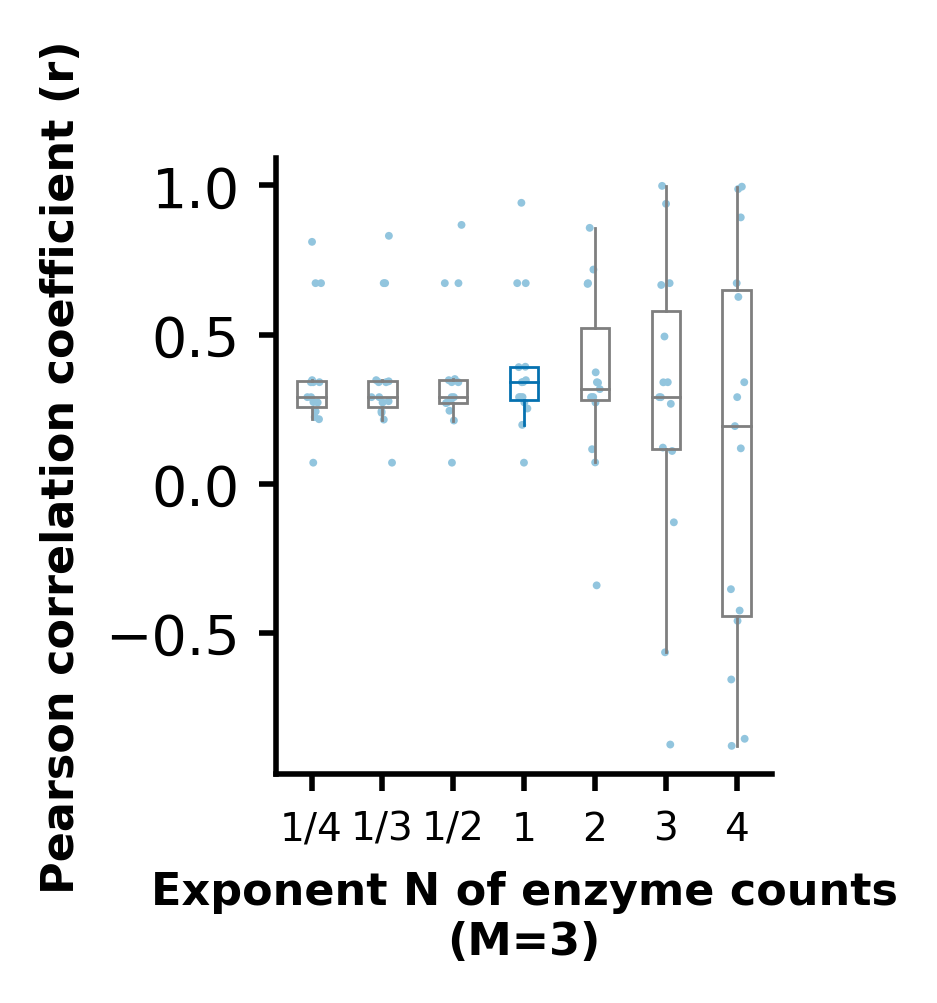

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

items = all_results_dict.items()
labels = ['1/4','1/3','1/2','1','2','3','4']
data = [v[:-1] for k, v in items]
positions = list(range(1, len(data)+1))

# ===== 全局设置（统一风格）=====
np.random.seed(0)
fig, ax = plt.subplots(figsize=(1.6, 2), dpi=400)

plt.rcParams.update({'font.size':9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# ===== boxplot =====
bp = ax.boxplot(data, positions=positions, widths=0.4, patch_artist=True, showfliers=False, showcaps=False)

edge_colors = ['#7F7F7F', '#7F7F7F', '#7F7F7F', '#0571b0', '#7F7F7F', '#7F7F7F', '#7F7F7F']

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('none')
    patch.set_edgecolor(edge_colors[i])
    patch.set_linewidth(0.5)

for i, line in enumerate(bp['whiskers']):
    line.set_color(edge_colors[i//2])
    line.set_linewidth(0.5)

for i, median in enumerate(bp['medians']):
    median.set_color(edge_colors[i])
    median.set_linewidth(0.5)


for i, group in enumerate(data):
    x_jittered = positions[i] + np.random.normal(0, 0.06, size=len(group))
    ax.scatter(x_jittered, group, color='#92c5de', edgecolors='none', s=2, zorder=1, alpha=1)

# ===== 坐标轴 =====
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=7)
ax.set_xlabel('Exponent N of enzyme counts\n(M=3)', fontsize=8, fontweight='bold')
ax.set_ylabel('Pearson correlation coefficient (r)', fontsize=8, fontweight='bold')

ax.tick_params(axis='y', direction='out', width=1, length=3)
ax.tick_params(axis='x', direction='out', width=1, length=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)


plt.savefig('../../Figure/Figure-2c1.pdf', dpi=400, bbox_inches='tight')
plt.show()
